# Artificial Intelligence – Exercise 1
## International Football Results (1872–2024): Exploratory Analysis

This notebook answers the **FOOTBALL ANALYSIS EXERCISE** questions using **pandas** and **matplotlib**.

**Dataset**: Kaggle — International Football Results (1872–2024)

> You must have `results.csv` available locally. Recommended location:
> - `../data/results.csv` (relative to this notebook)


## 1) Workspace setup (VS Code)

If you want to reproduce the folder structure in the integrated terminal (PowerShell):

```powershell
cd C:\Users\admin\Desktop\AI_Assignments
mkdir Football_Analysis_Exercise_1
mkdir Football_Analysis_Exercise_1\data
mkdir Football_Analysis_Exercise_1\notebooks
```

Then place the dataset CSV as:
- `Football_Analysis_Exercise_1/data/results.csv`

This notebook will try to load `../data/results.csv` first, then fall back to `results.csv` in the current working directory.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

# Optional: nicer default charts (safe if seaborn isn't installed)
try:
    import seaborn as sns

    sns.set_theme(style="whitegrid")
except Exception:
    pass

DATA_CANDIDATES = [
    Path("../data/results.csv"),
    Path("data/results.csv"),
    Path("results.csv"),
]

csv_path = next((p for p in DATA_CANDIDATES if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "Could not find results.csv. Put it in ../data/results.csv (recommended) or results.csv next to the notebook."
    )

df = pd.read_csv(csv_path)

# Parse dates for year-based questions
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Ensure scores are numeric
for col in ["home_score", "away_score"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

required_cols = ["date", "home_team", "away_team", "home_score", "away_score"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


## 2) Basic Exploration (Q1–Q4)

We’ll use:
- `len(df)` / `df.shape[0]` to count matches (rows).
- `df['date'].min()` / `max()` and `.dt.year` to get the year range.
- The union of `home_team` and `away_team` to count unique teams/countries.
- `value_counts()` to find the most frequent home team.


In [2]:
# Q1) How many matches are in the dataset?
num_matches = df.shape[0]
print(f"Q1) Number of matches (rows): {num_matches:,}")

# Q2) Earliest and latest year in the data
min_date = df["date"].min()
max_date = df["date"].max()
min_year = int(min_date.year) if pd.notna(min_date) else None
max_year = int(max_date.year) if pd.notna(max_date) else None
print(f"Q2) Earliest date: {min_date} (year={min_year})")
print(f"    Latest date:   {max_date} (year={max_year})")

# Q3) How many unique countries/teams are there?
teams = pd.concat([df["home_team"], df["away_team"]], ignore_index=True).dropna()
unique_teams = teams.nunique()
print(f"Q3) Unique teams/countries (home ∪ away): {unique_teams:,}")

# Q4) Which team appears most frequently as home team?
home_counts = df["home_team"].value_counts(dropna=True)
most_home_team = home_counts.index[0]
most_home_team_n = int(home_counts.iloc[0])
print(f"Q4) Most frequent home team: {most_home_team} ({most_home_team_n:,} matches as home)")

home_counts.head(10)

Q1) Number of matches (rows): 49,287
Q2) Earliest date: 1872-11-30 00:00:00 (year=1872)
    Latest date:   2026-06-27 00:00:00 (year=2026)
Q3) Unique teams/countries (home ∪ away): 333
Q4) Most frequent home team: Brazil (614 matches as home)


home_team
Brazil           614
Argentina        603
Mexico           602
Germany          555
England          550
South Korea      550
France           538
Sweden           534
United States    500
Hungary          497
Name: count, dtype: int64

## 3) Goals Analysis (Q5–Q8)

We create **total goals per match**:

$$\text{total\_goals} = \text{home\_score} + \text{away\_score}$$

Then we use:
- `mean()` for average goals
- `idxmax()` to locate the highest-scoring match
- `sum()` / `mean()` to compare home vs away scoring
- `value_counts()` to find the most common total-goals value (mode)


In [3]:
# Feature: total goals per match
# (If some scores are missing, total_goals will be NaN for those rows.)
df["total_goals"] = df["home_score"] + df["away_score"]

# Q5) Average number of goals per match
avg_goals = df["total_goals"].mean(skipna=True)
print(f"Q5) Average total goals per match: {avg_goals:.3f}")

# Q6) Highest scoring match (by total_goals)
max_idx = df["total_goals"].idxmax()
highest_scoring_match = df.loc[max_idx, [
    "date",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
    "total_goals",
    "tournament",
    "city",
    "country",
]].to_frame(name="value")
print("Q6) Highest scoring match (row with max total_goals):")
display(highest_scoring_match)

# Q7) Are more goals scored at home or away?
home_goals_sum = df["home_score"].sum(skipna=True)
away_goals_sum = df["away_score"].sum(skipna=True)
home_goals_mean = df["home_score"].mean(skipna=True)
away_goals_mean = df["away_score"].mean(skipna=True)

print(f"Q7) Total goals scored by HOME teams: {home_goals_sum:,.0f}")
print(f"    Total goals scored by AWAY teams: {away_goals_sum:,.0f}")
print(f"    Average home goals per match: {home_goals_mean:.3f}")
print(f"    Average away goals per match: {away_goals_mean:.3f}")
print("    Conclusion: More goals are scored by", "HOME" if home_goals_sum > away_goals_sum else "AWAY", "teams (by total sum).")

# Q8) Most common total_goals value (mode)
total_goals_counts = df["total_goals"].value_counts(dropna=True)
most_common_total_goals = int(total_goals_counts.index[0])
most_common_total_goals_n = int(total_goals_counts.iloc[0])
print(f"Q8) Most common total_goals value: {most_common_total_goals} (occurs {most_common_total_goals_n:,} times)")

total_goals_counts.head(10)

Q5) Average total goals per match: 2.938
Q6) Highest scoring match (row with max total_goals):


,value
date,2001-04-11 00:00:00
home_team,Australia
away_team,American Samoa
home_score,31.0
away_score,0.0
total_goals,31.0
tournament,FIFA World Cup qualification
city,Coffs Harbour
country,Australia


Q7) Total goals scored by HOME teams: 86,426
    Total goals scored by AWAY teams: 58,192
    Average home goals per match: 1.756
    Average away goals per match: 1.182
    Conclusion: More goals are scored by HOME teams (by total sum).
Q8) Most common total_goals value: 2 (occurs 10,927 times)


total_goals
2.0    10927
3.0     9724
1.0     8519
4.0     6822
5.0     4240
0.0     3956
6.0     2301
7.0     1257
8.0      643
9.0      354
Name: count, dtype: int64

## 4) Match Results (Q9–Q11)

We label each match outcome using the provided rules:
- `Home Win` if home score > away score
- `Away Win` if home score < away score
- `Draw` otherwise

Then:
- Q9 computes $p=\frac{\text{HomeWin}}{N}\times 100\%$
- Q10 compares home-win vs away-win rates to discuss home advantage
- Q11 counts winners (excluding draws) to find the team/country with most wins


In [4]:
def match_result(row):
    if row["home_score"] > row["away_score"]:
        return "Home Win"
    elif row["home_score"] < row["away_score"]:
        return "Away Win"
    else:
        return "Draw"

# Create match outcome label
# Note: if scores are missing (NaN), comparisons return False and will fall to "Draw".
# If you want to treat missing scores differently, filter them out before applying.
df["result"] = df.apply(match_result, axis=1)

result_counts = df["result"].value_counts(dropna=False)
print("Outcome counts:")
display(result_counts)

# Q9) Percentage of matches that are home wins
home_win_pct = (result_counts.get("Home Win", 0) / len(df)) * 100
away_win_pct = (result_counts.get("Away Win", 0) / len(df)) * 100
draw_pct = (result_counts.get("Draw", 0) / len(df)) * 100

print(f"Q9) Home win percentage: {home_win_pct:.2f}%")

# Q10) Does home advantage exist?
print("Q10) Home advantage check (rates over all matches):")
print(f"    Home Win: {home_win_pct:.2f}%")
print(f"    Away Win: {away_win_pct:.2f}%")
print(f"    Draw:     {draw_pct:.2f}%")

# Optional: compare only non-draw matches (conditional win rate)
non_draw = df[df["result"].isin(["Home Win", "Away Win"])].copy()
if len(non_draw) > 0:
    non_draw_counts = non_draw["result"].value_counts()
    home_win_given_not_draw = (non_draw_counts.get("Home Win", 0) / len(non_draw)) * 100
    away_win_given_not_draw = (non_draw_counts.get("Away Win", 0) / len(non_draw)) * 100
    print("    Conditional on non-draw matches:")
    print(f"      P(Home Win | not draw): {home_win_given_not_draw:.2f}%")
    print(f"      P(Away Win | not draw): {away_win_given_not_draw:.2f}%")

# Q11) Which country/team has the most wins historically?
# Winner is home_team for Home Win, away_team for Away Win, NaN for Draw.
df["winner"] = pd.NA
home_win_mask = df["result"] == "Home Win"
away_win_mask = df["result"] == "Away Win"
df.loc[home_win_mask, "winner"] = df.loc[home_win_mask, "home_team"]
df.loc[away_win_mask, "winner"] = df.loc[away_win_mask, "away_team"]

wins_by_team = df["winner"].value_counts(dropna=True)
most_wins_team = wins_by_team.index[0]
most_wins_n = int(wins_by_team.iloc[0])
print(f"Q11) Team/country with most wins: {most_wins_team} ({most_wins_n:,} wins)")

wins_by_team.head(10)

Outcome counts:


result
Home Win    24106
Away Win    13912
Draw        11269
Name: count, dtype: int64

Q9) Home win percentage: 48.91%
Q10) Home advantage check (rates over all matches):
    Home Win: 48.91%
    Away Win: 28.23%
    Draw:     22.86%
    Conditional on non-draw matches:
      P(Home Win | not draw): 63.41%
      P(Away Win | not draw): 36.59%
Q11) Team/country with most wins: Brazil (670 wins)


winner
Brazil         670
England        623
Germany        597
Argentina      588
Sweden         541
South Korea    536
Mexico         511
France         476
Italy          475
Hungary        470
Name: count, dtype: int64

## 5) Visualizations

We produce the three required plots:
- Histogram of `total_goals`
- Bar chart of match outcomes (`result`)
- Bar chart of top 10 teams by total wins (`winner`)


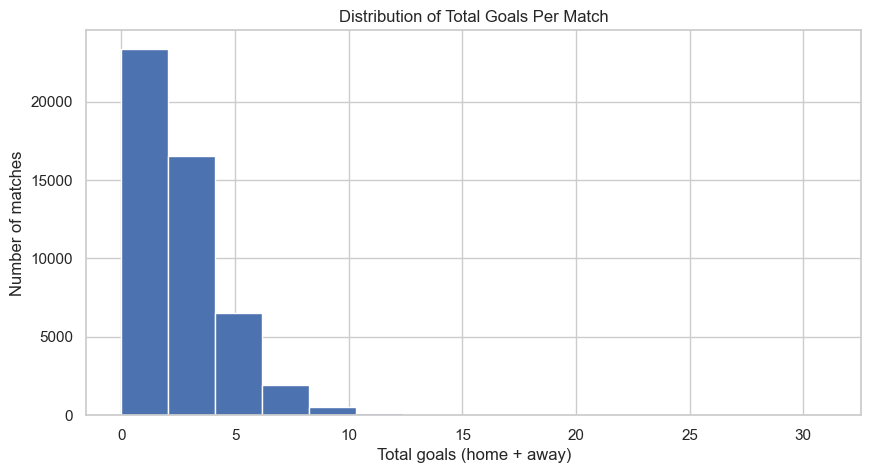

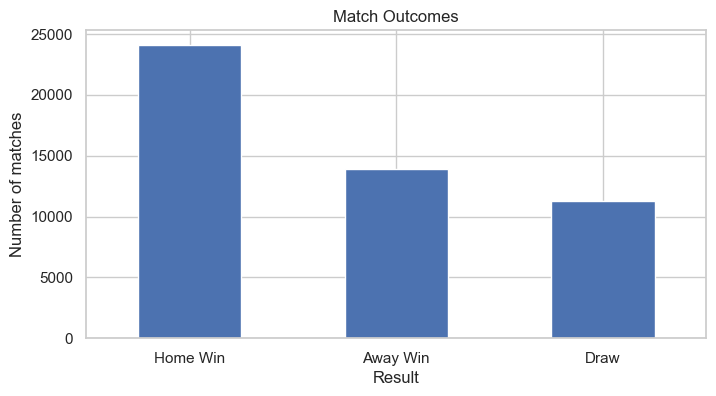

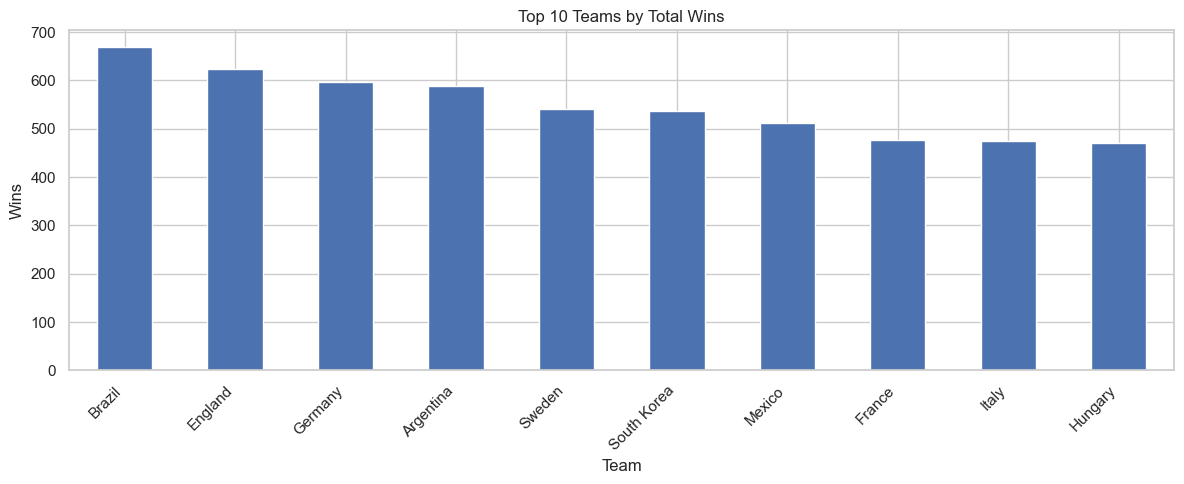

In [5]:
# Histogram of goals
plt.figure(figsize=(10, 5))
df["total_goals"].dropna().hist(bins=15)
plt.title("Distribution of Total Goals Per Match")
plt.xlabel("Total goals (home + away)")
plt.ylabel("Number of matches")
plt.show()

# Bar chart of match outcomes
plt.figure(figsize=(8, 4))
df["result"].value_counts().plot(kind="bar")
plt.title("Match Outcomes")
plt.xlabel("Result")
plt.ylabel("Number of matches")
plt.xticks(rotation=0)
plt.show()

# Top 10 teams by total wins
plt.figure(figsize=(12, 5))
wins_by_team.head(10).plot(kind="bar")
plt.title("Top 10 Teams by Total Wins")
plt.xlabel("Team")
plt.ylabel("Wins")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()